In [1]:
import os
import librosa
import soundfile as sf

INPUT_DIR = "/kaggle/input/datasets/jorisha/test-data3/test data3"   # مكان ملفاتك m4a
OUTPUT_DIR = "/kaggle/working/test_wav"  # مكان الحفظ بعد التحويل

os.makedirs(OUTPUT_DIR, exist_ok=True)

converted_files = []

for root, _, files in os.walk(INPUT_DIR):
    for f in files:
        if f.lower().endswith(".m4a"):
            input_path = os.path.join(root, f)
            output_path = os.path.join(OUTPUT_DIR, f.replace(".m4a", ".wav"))

            try:
                y, sr = librosa.load(input_path, sr=16000)
                sf.write(output_path, y, sr)
                converted_files.append(output_path)
            except Exception as e:
                print(f"Error with {f}: {e}")

print("Done converting:", len(converted_files))

/tmp/ipykernel_57/709623112.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(input_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_57/709623112.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(input_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_57/709623112.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(input_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/libro

Done converting: 28


/tmp/ipykernel_57/709623112.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(input_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [2]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import ASTModel, ASTFeatureExtractor      
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# عدلي المسارات عندك
BACKBONE_DIR = "MIT/ast-finetuned-audioset-10-10-0.4593"
TEST_DIR = "/kaggle/working/test_wav"   # تسجيلاتك الخارجية

feature_extractor = ASTFeatureExtractor.from_pretrained(BACKBONE_DIR)
ast_backbone = ASTModel.from_pretrained(BACKBONE_DIR)

TARGET_SR = feature_extractor.sampling_rate
ast_backbone.to(DEVICE)
print("Loaded original pretrained AST backbone")
print("Sampling rate:", TARGET_SR)

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded original pretrained AST backbone
Sampling rate: 16000


In [3]:
AUDIO_BASE = "/kaggle/input/datasets/antonygarciag/fall-audio-detection-dataset"  # عدليه لمسار SAFE عندك

records = []

for root, _, files in os.walk(AUDIO_BASE):
    for f in files:
        if not f.lower().endswith(".wav"):
            continue

        path = os.path.join(root, f)
        base = os.path.splitext(f)[0]

        try:
            aa, bbb, cc, ddd, ff = base.split("-")
        except ValueError:
            continue

        binary_label = "Fall" if ff == "01" else "No-Fall"

        records.append({
            "filename": f,
            "filepath": path,
            "AA": aa,
            "Binary_Label": binary_label,
        })

df_safe = pd.DataFrame(records)
print("Total SAFE files:", len(df_safe))
print(df_safe["Binary_Label"].value_counts())
df_safe.head()

Total SAFE files: 950
Binary_Label
No-Fall    475
Fall       475
Name: count, dtype: int64


,filename,filepath,AA,Binary_Label
0,04-246-00-006-02.wav,/kaggle/input/datasets/antonygarciag/fall-audi...,04,No-Fall
1,07-272-00-107-02.wav,/kaggle/input/datasets/antonygarciag/fall-audi...,07,No-Fall
2,07-566-01-048-01.wav,/kaggle/input/datasets/antonygarciag/fall-audi...,07,Fall
3,02-520-04-075-01.wav,/kaggle/input/datasets/antonygarciag/fall-audi...,02,Fall
4,06-074-00-185-02.wav,/kaggle/input/datasets/antonygarciag/fall-audi...,06,No-Fall


In [4]:
CONVERTED_DIR = "/kaggle/working/test_wav_A"
os.makedirs(CONVERTED_DIR, exist_ok=True)

converted_files = []

for root, _, files in os.walk(TEST_DIR):
    for f in files:
        input_path = os.path.join(root, f)

        if f.lower().endswith(".m4a"):
            output_name = f[:-4] + ".wav"
            output_path = os.path.join(CONVERTED_DIR, output_name)
            try:
                y, sr = librosa.load(input_path, sr=TARGET_SR)
                sf.write(output_path, y, sr)
                converted_files.append(output_path)
            except Exception as e:
                print(f"Error converting {f}: {e}")

        elif f.lower().endswith(".wav"):
            output_path = os.path.join(CONVERTED_DIR, f)
            try:
                y, sr = librosa.load(input_path, sr=TARGET_SR)
                sf.write(output_path, y, sr)
                converted_files.append(output_path)
            except Exception as e:
                print(f"Error copying/re-encoding {f}: {e}")

print("Converted/prepared files:", len(converted_files))
print(converted_files[:5])

Converted/prepared files: 28
['/kaggle/working/test_wav_A/spoon fall on carbet.wav', '/kaggle/working/test_wav_A/spoon fall.wav', '/kaggle/working/test_wav_A/body fall layeng 100 m ceramic.wav', '/kaggle/working/test_wav_A/body fall on ceramic.wav', '/kaggle/working/test_wav_A/body fall 100 m ceramic.wav']


In [5]:
def get_external_binary_label(fname):
    fname = fname.lower()

    if "body" in fname:
        return "Fall"
    elif "object" in fname or "box" in fname or "spoon" in fname or "cup" in fname:
        return "No-Fall"
    else:
        return None

ext_records = []

for fpath in converted_files:
    fname = os.path.basename(fpath)
    lbl = get_external_binary_label(fname)
    if lbl is None:
        continue

    ext_records.append({
        "filename": fname,
        "filepath": fpath,
        "AA": "EXT",  # عشان نميزه
        "Binary_Label": lbl,
        "source": "external"
    })

df_ext = pd.DataFrame(ext_records)
print("External usable files:", len(df_ext))
print(df_ext["Binary_Label"].value_counts())
df_ext.head()

External usable files: 28
Binary_Label
Fall       16
No-Fall    12
Name: count, dtype: int64


,filename,filepath,AA,Binary_Label,source
0,spoon fall on carbet.wav,/kaggle/working/test_wav_A/spoon fall on carbe...,EXT,No-Fall,external
1,spoon fall.wav,/kaggle/working/test_wav_A/spoon fall.wav,EXT,No-Fall,external
2,body fall layeng 100 m ceramic.wav,/kaggle/working/test_wav_A/body fall layeng 10...,EXT,Fall,external
3,body fall on ceramic.wav,/kaggle/working/test_wav_A/body fall on cerami...,EXT,Fall,external
4,body fall 100 m ceramic.wav,/kaggle/working/test_wav_A/body fall 100 m cer...,EXT,Fall,external


In [6]:
train_folds = ["01", "02", "03", "04", "05", "06", "07", "08"]
val_folds   = ["09", "10"]

df_train_safe = df_safe[df_safe["AA"].isin(train_folds)].reset_index(drop=True)
df_val_safe   = df_safe[df_safe["AA"].isin(val_folds)].reset_index(drop=True)

print("SAFE train:")
print(df_train_safe["Binary_Label"].value_counts(), "\n")

print("SAFE val:")
print(df_val_safe["Binary_Label"].value_counts())

SAFE train:
Binary_Label
Fall       384
No-Fall    376
Name: count, dtype: int64 

SAFE val:
Binary_Label
No-Fall    99
Fall       91
Name: count, dtype: int64


In [7]:
label_map_bin = {"Fall": 0, "No-Fall": 1}
idx_to_class_bin = {v: k for k, v in label_map_bin.items()}

print(label_map_bin)
print(idx_to_class_bin)

{'Fall': 0, 'No-Fall': 1}
{0: 'Fall', 1: 'No-Fall'}


In [8]:
class FallBinaryDataset(Dataset):
    def __init__(self, df_split):
        self.df = df_split.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        y, _ = librosa.load(row["filepath"], sr=TARGET_SR)
        y = torch.tensor(y, dtype=torch.float32)

        label_idx = label_map_bin[row["Binary_Label"]]
        return y, label_idx

def ast_collate_bin(batch):
    waves, labels = zip(*batch)
    wave_list = [w.numpy() for w in waves]

    ast_inputs = feature_extractor(
        wave_list,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    labels = torch.tensor(labels, dtype=torch.long)
    return ast_inputs, labels

In [15]:
train_ds = FallBinaryDataset(df_train_safe)
val_ds   = FallBinaryDataset(df_val_safe)

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=ast_collate_bin)
val_dl   = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=ast_collate_bin)

print("Train batches:", len(train_dl))
print("Val batches:", len(val_dl))

Train batches: 95
Val batches: 24


In [16]:
class ASTBinary(nn.Module):
    def __init__(self, ast_backbone, num_classes=2, freeze_backbone=False, dropout=0.3):
        super().__init__()
        self.ast = ast_backbone

        if freeze_backbone:
            for p in self.ast.parameters():
                p.requires_grad = False

        hidden_dim = self.ast.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, ast_inputs):
        outputs = self.ast(**ast_inputs)

        if getattr(outputs, "pooler_output", None) is not None:
            feats = outputs.pooler_output
        else:
            feats = outputs.last_hidden_state.mean(dim=1)

        feats = self.dropout(feats)
        logits = self.classifier(feats)
        return logits

In [17]:
y_train = df_train_safe["Binary_Label"].map(label_map_bin).values
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print("Class weights:", weights)

Class weights: tensor([0.9896, 1.0106], device='cuda:0')


In [18]:
modelA = ASTBinary(
    ast_backbone,
    num_classes=2,
    freeze_backbone=False,
    dropout=0.3
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(
    modelA.parameters(),
    lr=5e-5,
    weight_decay=1e-3
)

In [19]:
EPOCHS = 10
patience = 3
counter = 0

best_val_loss = float("inf")
best_val_acc = 0.0

train_hist = []
val_hist = []
train_loss_hist = []
val_loss_hist = []

for epoch in range(1, EPOCHS + 1):
    # ---------------- TRAIN ----------------
    modelA.train()
    total = 0
    correct = 0
    running_loss = 0.0

    for ast_inputs, labels in train_dl:
        ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = modelA(ast_inputs)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelA.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---------------- VAL ----------------
    modelA.eval()
    v_total = 0
    v_correct = 0
    v_running_loss = 0.0

    with torch.no_grad():
        for ast_inputs, labels in val_dl:
            ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
            labels = labels.to(DEVICE)

            logits = modelA(ast_inputs)
            loss = criterion(logits, labels)

            v_running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    val_loss = v_running_loss / v_total
    val_acc = v_correct / v_total

    train_hist.append(train_acc)
    val_hist.append(val_acc)
    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        counter = 0
        torch.save(modelA.state_dict(), "best_stageA_fall_detector.pth")
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("Best validation accuracy:", best_val_acc)
print("Best validation loss:", best_val_loss)

Epoch 01 | train_loss=0.2515 train_acc=0.943 | val_loss=0.0637 val_acc=0.989
Epoch 02 | train_loss=0.0418 train_acc=0.989 | val_loss=0.0087 val_acc=0.995
Epoch 03 | train_loss=0.0586 train_acc=0.987 | val_loss=0.1259 val_acc=0.979
Epoch 04 | train_loss=0.0759 train_acc=0.988 | val_loss=0.0104 val_acc=0.995
Epoch 05 | train_loss=0.0000 train_acc=1.000 | val_loss=0.0974 val_acc=0.984
Early stopping at epoch 5
Best validation accuracy: 0.9947368421052631
Best validation loss: 0.008653364052933236


              precision    recall  f1-score   support

        Fall       0.99      1.00      0.99        91
     No-Fall       1.00      0.99      0.99        99

    accuracy                           0.99       190
   macro avg       0.99      0.99      0.99       190
weighted avg       0.99      0.99      0.99       190

[[91  0]
 [ 1 98]]


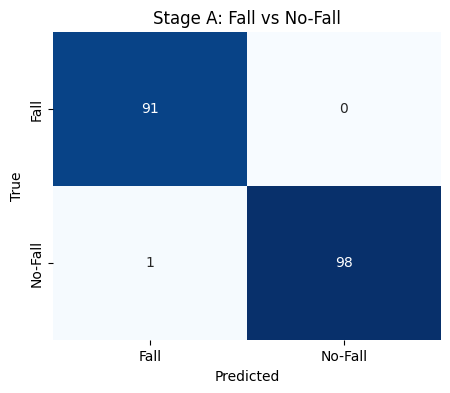

In [20]:
modelA.load_state_dict(torch.load("best_stageA_fall_detector.pth", map_location=DEVICE))
modelA.to(DEVICE)
modelA.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for ast_inputs, labels in val_dl:
        ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
        labels = labels.to(DEVICE)

        logits = modelA(ast_inputs)
        preds = logits.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

print(classification_report(
    all_labels,
    all_preds,
    target_names=[idx_to_class_bin[i] for i in range(2)]
))

cm = confusion_matrix(all_labels, all_preds)
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[idx_to_class_bin[i] for i in range(2)],
    yticklabels=[idx_to_class_bin[i] for i in range(2)],
    cbar=False
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Stage A: Fall vs No-Fall")
plt.show()

In [21]:
import torch.nn.functional as F

def predict_stageA(file_path, min_len=400):
    try:
        y, _ = librosa.load(file_path, sr=TARGET_SR, mono=True)
    except Exception as e:
        return {
            "file": file_path,
            "status": f"load_error: {e}",
            "prediction": None,
            "confidence": None
        }

    if y is None or len(y) == 0:
        return {
            "file": file_path,
            "status": "empty_audio",
            "prediction": None,
            "confidence": None
        }

    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)), mode="constant")

    inputs = feature_extractor(
        [y],
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = modelA(inputs)
        probs = F.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        pred_label = idx_to_class_bin[pred_idx]
        conf = probs.max(dim=1).values.item()

    return {
        "file": file_path,
        "status": "ok",
        "prediction": pred_label,
        "confidence": conf
    }

In [22]:
results_ext = []

for f in converted_files:
    out = predict_stageA(f)
    results_ext.append(out)

df_ext_results = pd.DataFrame(results_ext)

def get_true_type(fname):
    fname = fname.lower()
    if "body" in fname:
        return "Fall"
    elif "object" in fname or "box" in fname or "spoon" in fname or "cup" in fname:
        return "No-Fall"
    return "unknown"

df_ext_results["true_type"] = df_ext_results["file"].apply(lambda x: get_true_type(os.path.basename(x)))

print(df_ext_results.groupby(["true_type", "prediction"]).size())
display(df_ext_results[["file", "true_type", "prediction", "confidence"]].sort_values("confidence", ascending=False))

true_type  prediction
Fall       Fall           2
           No-Fall       14
No-Fall    Fall           1
           No-Fall       11
dtype: int64


,file,true_type,prediction,confidence
22,/kaggle/working/test_wav_A/spoon fall on carbe...,No-Fall,No-Fall,0.999991
19,/kaggle/working/test_wav_A/cup on carbet.wav,No-Fall,No-Fall,0.999990
15,/kaggle/working/test_wav_A/object fall on carb...,No-Fall,No-Fall,0.999990
24,/kaggle/working/test_wav_A/body fall laying100...,Fall,No-Fall,0.999990
16,/kaggle/working/test_wav_A/body fall laying100...,Fall,No-Fall,0.999989
27,/kaggle/working/test_wav_A/object fall on carb...,No-Fall,No-Fall,0.999989
6,/kaggle/working/test_wav_A/body fall layeng ca...,Fall,No-Fall,0.999988
11,/kaggle/working/test_wav_A/body fall layeng on...,Fall,No-Fall,0.999987
7,/kaggle/working/test_wav_A/body fall on carbet...,Fall,No-Fall,0.999987
3,/kaggle/working/test_wav_A/body fall layeng o...,Fall,No-Fall,0.999986


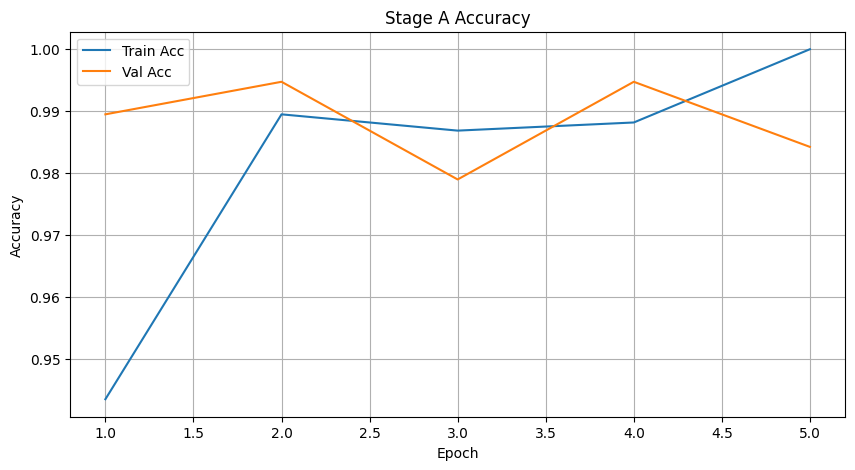

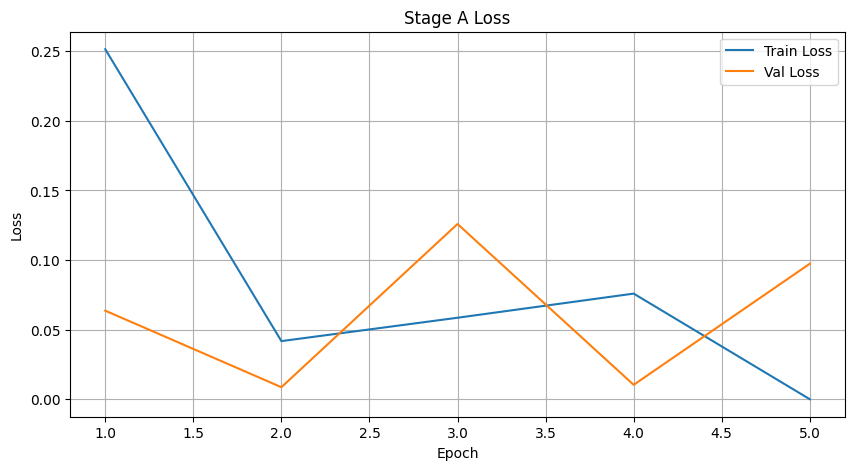

In [23]:
epochs = range(1, len(train_hist) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_hist, label="Train Acc")
plt.plot(epochs, val_hist, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage A Accuracy") 
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss_hist, label="Train Loss")
plt.plot(epochs, val_loss_hist, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage A Loss")
plt.legend()
plt.grid()
plt.show()

In [11]:
# =========================================================
# STAGE B: Fine-tune Stage A on SAFE + External
# Task: Fall vs No-Fall
# =========================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import librosa

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import ASTModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [12]:
# =========================================================
# 1) External data split
# df_ext لازم يكون فيه:
# filename, filepath, Binary_Label
# Binary_Label = Fall / No-Fall
# =========================================================

df_ext = df_ext[df_ext["Binary_Label"].isin(["Fall", "No-Fall"])].copy()

df_ext_train, df_ext_val = train_test_split(
    df_ext,
    test_size=0.30,
    stratify=df_ext["Binary_Label"],
    random_state=42
)

df_ext_train = df_ext_train.reset_index(drop=True)
df_ext_val = df_ext_val.reset_index(drop=True)

print("External train:")
print(df_ext_train["Binary_Label"].value_counts())

print("\nExternal val:")
print(df_ext_val["Binary_Label"].value_counts())

External train:
Binary_Label
Fall       11
No-Fall     8
Name: count, dtype: int64

External val:
Binary_Label
Fall       5
No-Fall    4
Name: count, dtype: int64


In [13]:
# =========================================================
# 2) Build Stage B train / validation
# Train = SAFE train + external train
# Val   = SAFE val   + external val
# =========================================================

df_train_B = pd.concat(
    [df_train_safe, df_ext_train],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

df_val_B = pd.concat(
    [df_val_safe, df_ext_val],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

print("Stage B train:")
print(df_train_B["Binary_Label"].value_counts())

print("\nStage B validation:")
print(df_val_B["Binary_Label"].value_counts())

Stage B train:
Binary_Label
Fall       395
No-Fall    384
Name: count, dtype: int64

Stage B validation:
Binary_Label
No-Fall    103
Fall        96
Name: count, dtype: int64


In [14]:
# =========================================================
# 3) Labels
# =========================================================

label_map_B = {"Fall": 0, "No-Fall": 1}
idx_to_class_B = {0: "Fall", 1: "No-Fall"}

print(label_map_B)
print(idx_to_class_B)

{'Fall': 0, 'No-Fall': 1}
{0: 'Fall', 1: 'No-Fall'}


In [15]:
# =========================================================
# 4) Dataset + collate
# =========================================================

class StageBDataset(Dataset):
    def __init__(self, df_split):
        self.df = df_split.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        y, _ = librosa.load(row["filepath"], sr=TARGET_SR, mono=True)
        y = torch.tensor(y, dtype=torch.float32)

        label = label_map_B[row["Binary_Label"]]
        return y, label


def ast_collate_B(batch):
    waves, labels = zip(*batch)
    wave_list = [w.numpy() for w in waves]

    ast_inputs = feature_extractor(
        wave_list,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    labels = torch.tensor(labels, dtype=torch.long)
    return ast_inputs, labels


train_ds_B = StageBDataset(df_train_B)
val_ds_B = StageBDataset(df_val_B)

train_dl_B = DataLoader(
    train_ds_B,
    batch_size=8,
    shuffle=True,
    collate_fn=ast_collate_B
)

val_dl_B = DataLoader(
    val_ds_B,
    batch_size=8,
    shuffle=False,
    collate_fn=ast_collate_B
)

print("Train batches:", len(train_dl_B))
print("Val batches:", len(val_dl_B))

Train batches: 98
Val batches: 25


In [16]:
# =========================================================
# 5) Model architecture
# نفس architecture حق Stage A
# =========================================================

class ASTFallDetector(nn.Module):
    def __init__(self, ast_backbone, num_classes=2, freeze_backbone=False, dropout=0.3):
        super().__init__()
        self.ast = ast_backbone

        if freeze_backbone:
            for p in self.ast.parameters():
                p.requires_grad = False

        hidden_dim = self.ast.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, ast_inputs):
        outputs = self.ast(**ast_inputs)

        if getattr(outputs, "pooler_output", None) is not None:
            feats = outputs.pooler_output
        else:
            feats = outputs.last_hidden_state.mean(dim=1)

        feats = self.dropout(feats)
        logits = self.classifier(feats)
        return logits

In [28]:
# =========================================================
# 6) Load Stage A weights into Stage B
# =========================================================

STAGEA_WEIGHTS = "/kaggle/working/best_stageA_fall_detector.pth"
# أو إذا اسمك مختلف:
# STAGEA_WEIGHTS = "/kaggle/working/best_stageA_fall_detector.pth"

ast_backbone_B = ASTModel.from_pretrained(BACKBONE_DIR)

modelB = ASTFallDetector(
    ast_backbone=ast_backbone_B,
    num_classes=2,
    freeze_backbone=False,
    dropout=0.3
).to(DEVICE)

modelB.load_state_dict(
    torch.load(STAGEA_WEIGHTS, map_location=DEVICE)
)

print("Stage B initialized from Stage A weights.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/best_stageA_fall_detector.pth'

In [17]:
# =========================================================
# 7) Loss + optimizer
# =========================================================

y_train_B = df_train_B["Binary_Label"].map(label_map_B).values

classes_B = np.array([0, 1])
weights_B = compute_class_weight(
    class_weight="balanced",
    classes=classes_B,
    y=y_train_B
)

weights_B = torch.tensor(weights_B, dtype=torch.float).to(DEVICE)
print("Class weights:", weights_B)

criterion_B = nn.CrossEntropyLoss(weight=weights_B)

optimizer_B = torch.optim.AdamW(
    modelB.parameters(),
    lr=5e-6,          # صغير لأنه fine-tuning
    weight_decay=1e-3
)

Class weights: tensor([0.9861, 1.0143], device='cuda:0')


In [40]:
# =========================================================
# 8) Train Stage B
# =========================================================

EPOCHS = 8
patience = 3

best_val_loss_B = float("inf")
best_val_acc_B = 0.0
counter = 0

train_acc_hist_B = []
val_acc_hist_B = []
train_loss_hist_B = []
val_loss_hist_B = []

SAVE_B_PATH = "/kaggle/working/modelB_SAFE_plus_external_valmix.pth"

for epoch in range(1, EPOCHS + 1):

    # ---------- TRAIN ----------
    modelB.train()
    total = 0
    correct = 0
    running_loss = 0.0

    for ast_inputs, labels in train_dl_B:
        ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
        labels = labels.to(DEVICE)

        optimizer_B.zero_grad()

        logits = modelB(ast_inputs)
        loss = criterion_B(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelB.parameters(), 1.0)
        optimizer_B.step()

        running_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---------- VALIDATION ----------
    modelB.eval()
    v_total = 0
    v_correct = 0
    v_running_loss = 0.0

    with torch.no_grad():
        for ast_inputs, labels in val_dl_B:
            ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
            labels = labels.to(DEVICE)

            logits = modelB(ast_inputs)
            loss = criterion_B(logits, labels)

            v_running_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    val_loss = v_running_loss / v_total
    val_acc = v_correct / v_total

    train_acc_hist_B.append(train_acc)
    val_acc_hist_B.append(val_acc)
    train_loss_hist_B.append(train_loss)
    val_loss_hist_B.append(val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

    if val_loss < best_val_loss_B:
        best_val_loss_B = val_loss
        best_val_acc_B = val_acc
        counter = 0
        torch.save(modelB.state_dict(), SAVE_B_PATH)
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("Best Stage B validation accuracy:", best_val_acc_B)
print("Best Stage B validation loss:", best_val_loss_B)
print("Saved:", SAVE_B_PATH)

Epoch 01 | train_loss=0.1015 train_acc=0.985 | val_loss=0.0442 val_acc=0.985
Epoch 02 | train_loss=0.0520 train_acc=0.987 | val_loss=0.0501 val_acc=0.995
Epoch 03 | train_loss=0.0044 train_acc=0.997 | val_loss=0.0110 val_acc=0.990
Epoch 04 | train_loss=0.0022 train_acc=0.999 | val_loss=0.0862 val_acc=0.985
Epoch 05 | train_loss=0.0000 train_acc=1.000 | val_loss=0.0967 val_acc=0.985
Epoch 06 | train_loss=0.0000 train_acc=1.000 | val_loss=0.0994 val_acc=0.985
Early stopping at epoch 6
Best Stage B validation accuracy: 0.9899497487437185
Best Stage B validation loss: 0.011032412625034559
Saved: /kaggle/working/modelB_SAFE_plus_external_valmix.pth


In [41]:
# =========================================================
# 9) Evaluate Stage B on mixed validation
# SAFE val + external val
# =========================================================

modelB.load_state_dict(torch.load(SAVE_B_PATH, map_location=DEVICE))
modelB.to(DEVICE)
modelB.eval()

all_labels_B = []
all_preds_B = []

with torch.no_grad():
    for ast_inputs, labels in val_dl_B:
        ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
        labels = labels.to(DEVICE)

        logits = modelB(ast_inputs)
        preds = logits.argmax(dim=1)

        all_labels_B.extend(labels.cpu().numpy().tolist())
        all_preds_B.extend(preds.cpu().numpy().tolist())

print("=== Stage B: SAFE + External Validation ===")
print(classification_report(
    all_labels_B,
    all_preds_B,
    target_names=[idx_to_class_B[i] for i in range(2)],
    zero_division=0
))

cm_B = confusion_matrix(all_labels_B, all_preds_B)
print("Confusion Matrix:")
print(cm_B)

=== Stage B: SAFE + External Validation ===
              precision    recall  f1-score   support

        Fall       1.00      0.98      0.99        96
     No-Fall       0.98      1.00      0.99       103

    accuracy                           0.99       199
   macro avg       0.99      0.99      0.99       199
weighted avg       0.99      0.99      0.99       199

Confusion Matrix:
[[ 94   2]
 [  0 103]]


In [42]:
# =========================================================
# 10) Evaluate separately: SAFE val only and External val only
# هذا مهم عشان تعرفي هل فعلاً تحسن على object falls
# =========================================================

def evaluate_on_df(model, df_eval, title):
    ds = StageBDataset(df_eval)
    dl = DataLoader(ds, batch_size=8, shuffle=False, collate_fn=ast_collate_B)

    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for ast_inputs, labels in dl:
            ast_inputs = {k: v.to(DEVICE) for k, v in ast_inputs.items()}
            labels = labels.to(DEVICE)

            logits = model(ast_inputs)
            preds = logits.argmax(dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    print(f"\n=== {title} ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_class_B[i] for i in range(2)],
        zero_division=0
    ))
    print(confusion_matrix(y_true, y_pred))


evaluate_on_df(modelB, df_val_safe, "Stage B on SAFE validation only")
evaluate_on_df(modelB, df_ext_val, "Stage B on External validation only")


=== Stage B on SAFE validation only ===
              precision    recall  f1-score   support

        Fall       1.00      0.99      0.99        91
     No-Fall       0.99      1.00      0.99        99

    accuracy                           0.99       190
   macro avg       0.99      0.99      0.99       190
weighted avg       0.99      0.99      0.99       190

[[90  1]
 [ 0 99]]

=== Stage B on External validation only ===
              precision    recall  f1-score   support

        Fall       1.00      0.80      0.89         5
     No-Fall       0.80      1.00      0.89         4

    accuracy                           0.89         9
   macro avg       0.90      0.90      0.89         9
weighted avg       0.91      0.89      0.89         9

[[4 1]
 [0 4]]
